<a href="https://colab.research.google.com/github/tipchuwis/blackjack/blob/main/silly_catmera2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
https://universe.roboflow.com/ds/gzaexTTQ5C?key=L4ouf6Ryy0

SyntaxError: invalid syntax (375847356.py, line 1)

In [ ]:
!nvidia-smi

Sun Mar  1 05:30:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics

In [ ]:
import ultralytics

ultralytics.checks()

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.4/112.6 GB disk)


In [ ]:
from ultralytics import YOLO

from IPython.display import Image

In [ ]:
!pip install roboflow

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="zWHqdHiB5pZyxJdGF4Dt")

project = rf.workspace("stress-detection-wnra9").project("facial-emotion-detection-mlrex")

version = project.version(1)

dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Facial-Emotion-Detection-1 in yolov11:: 100%|██████████| 13336/13336 [00:01<00:00, 8402.17it/s] 


In [ ]:
dataset.location

'/content/Facial-Emotion-Detection-1'

In [ ]:
!yolo task=detect mode=train data={dataset.location}/data.yaml model=yolo11n.pt epochs=10 imgsz=640

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Facial-Emotion-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

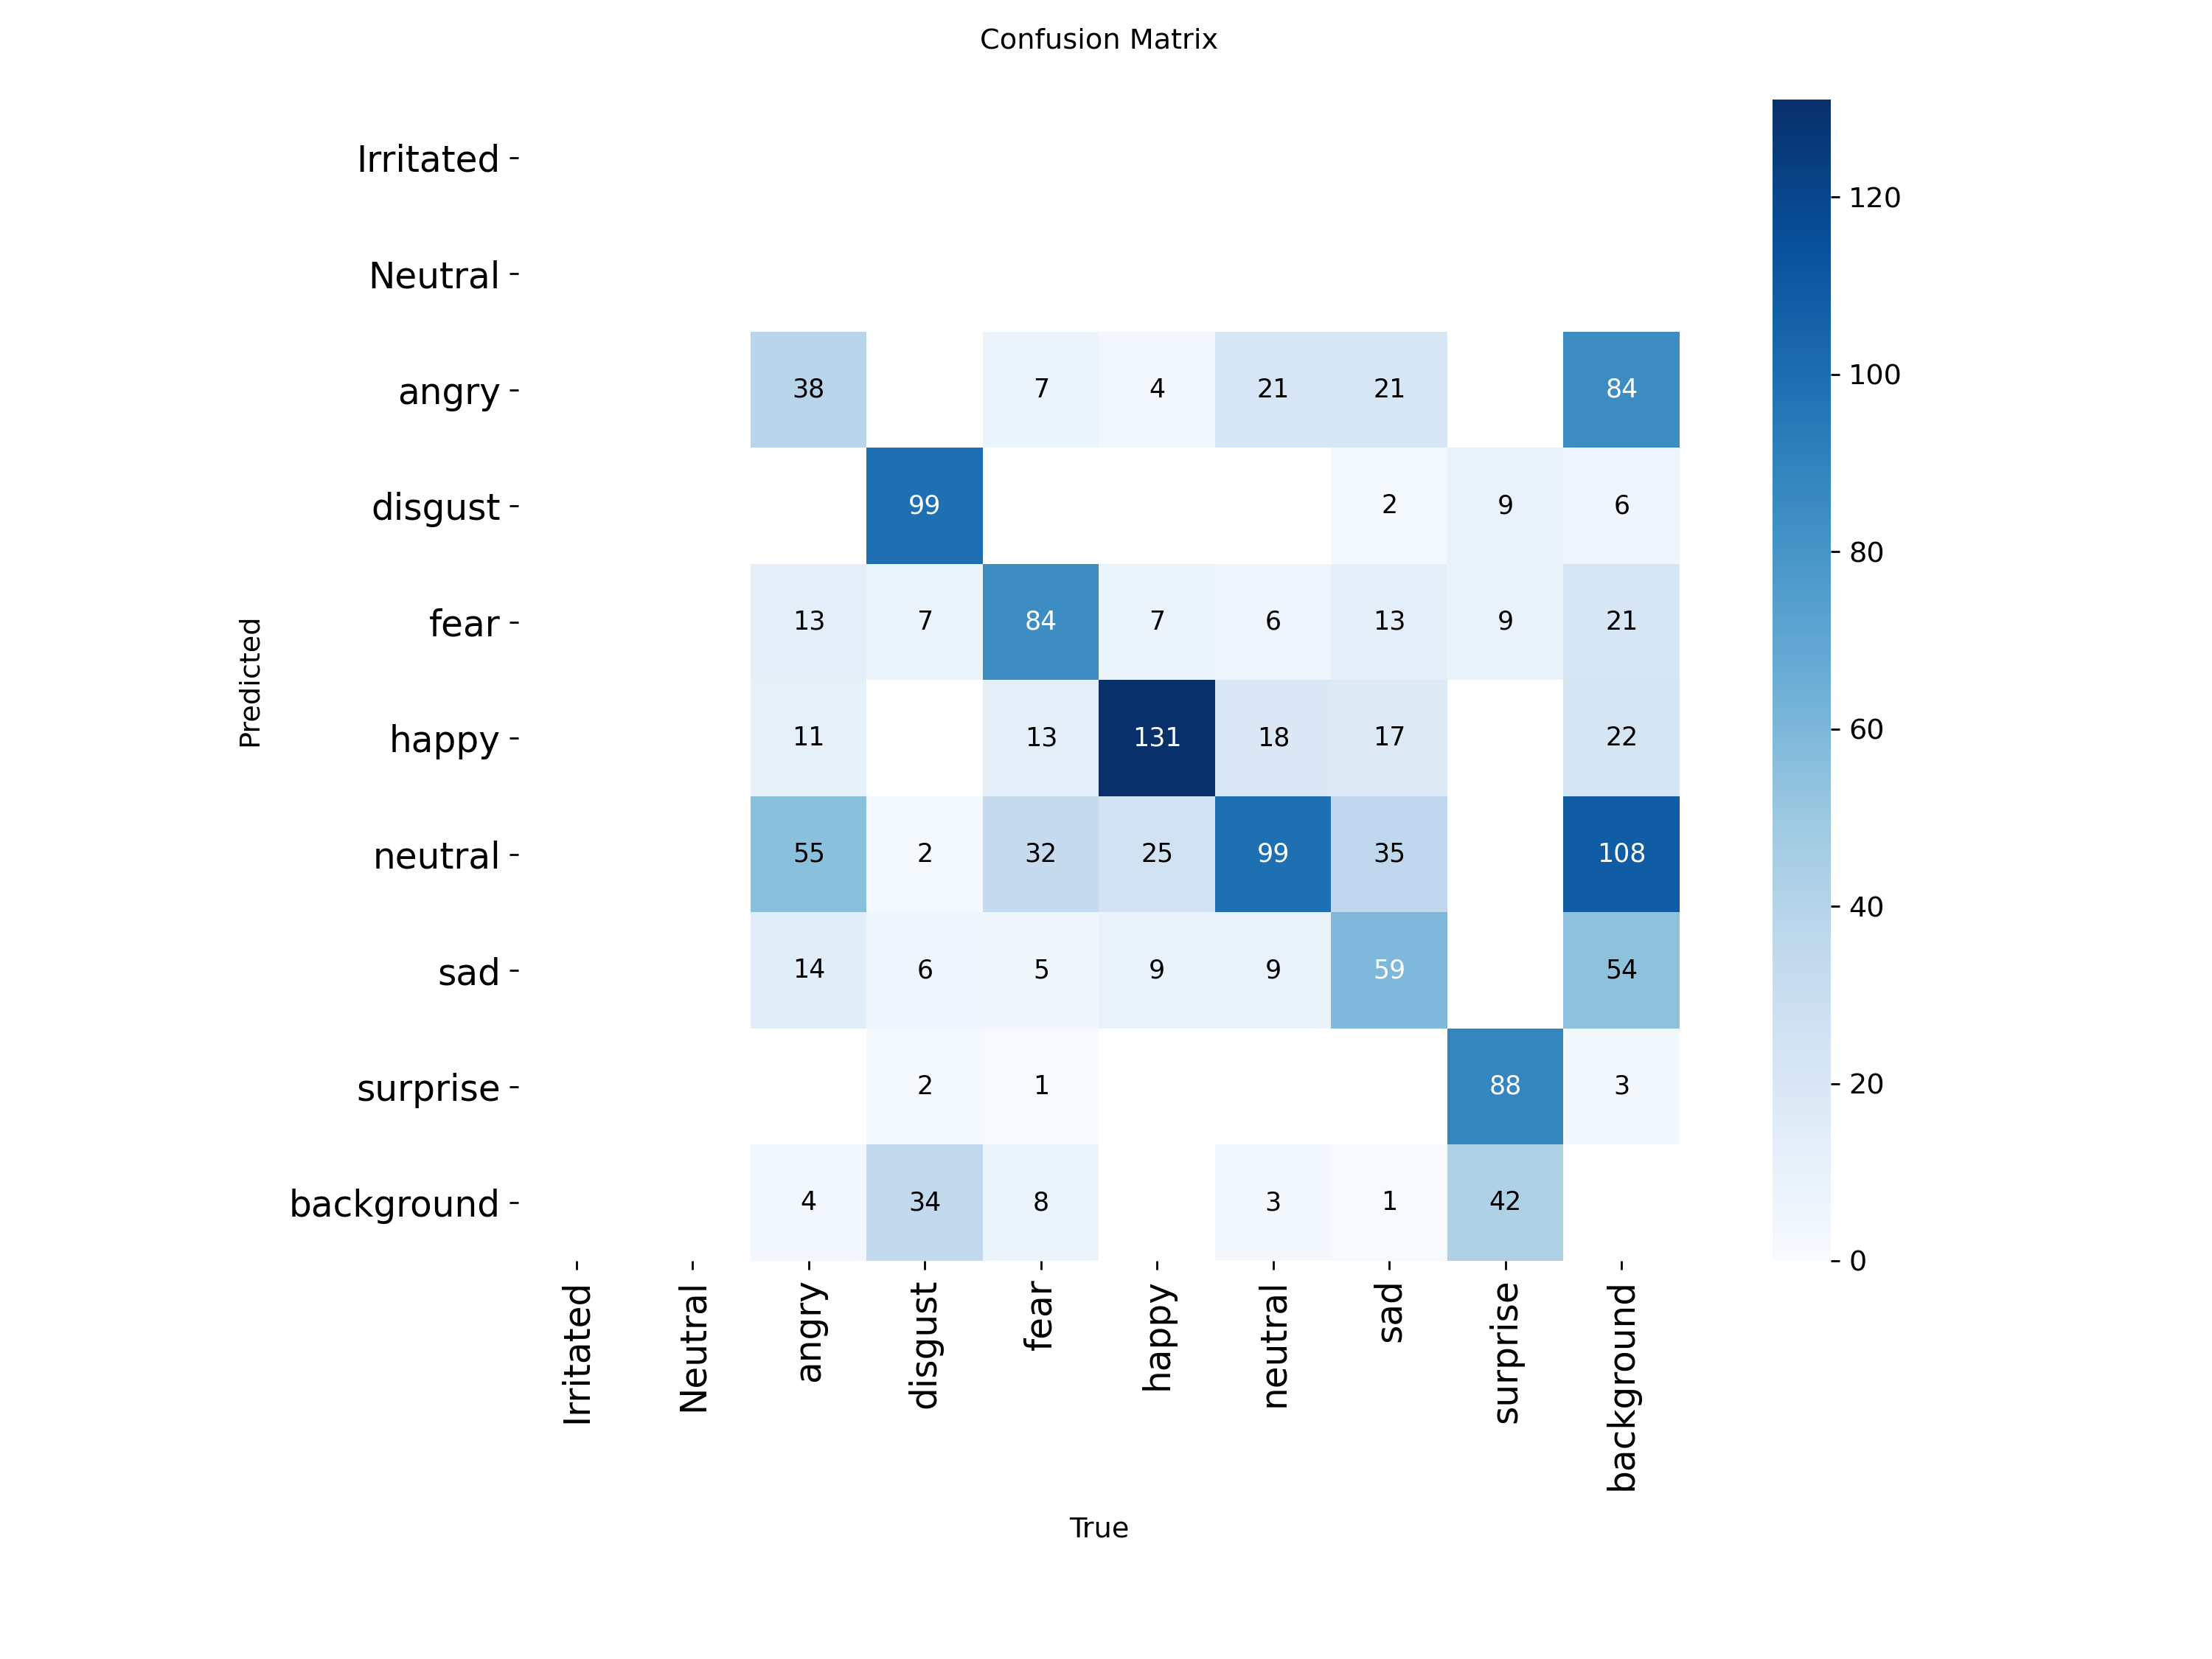

In [ ]:
Image("/content/runs/detect/train/confusion_matrix.png", width=600)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


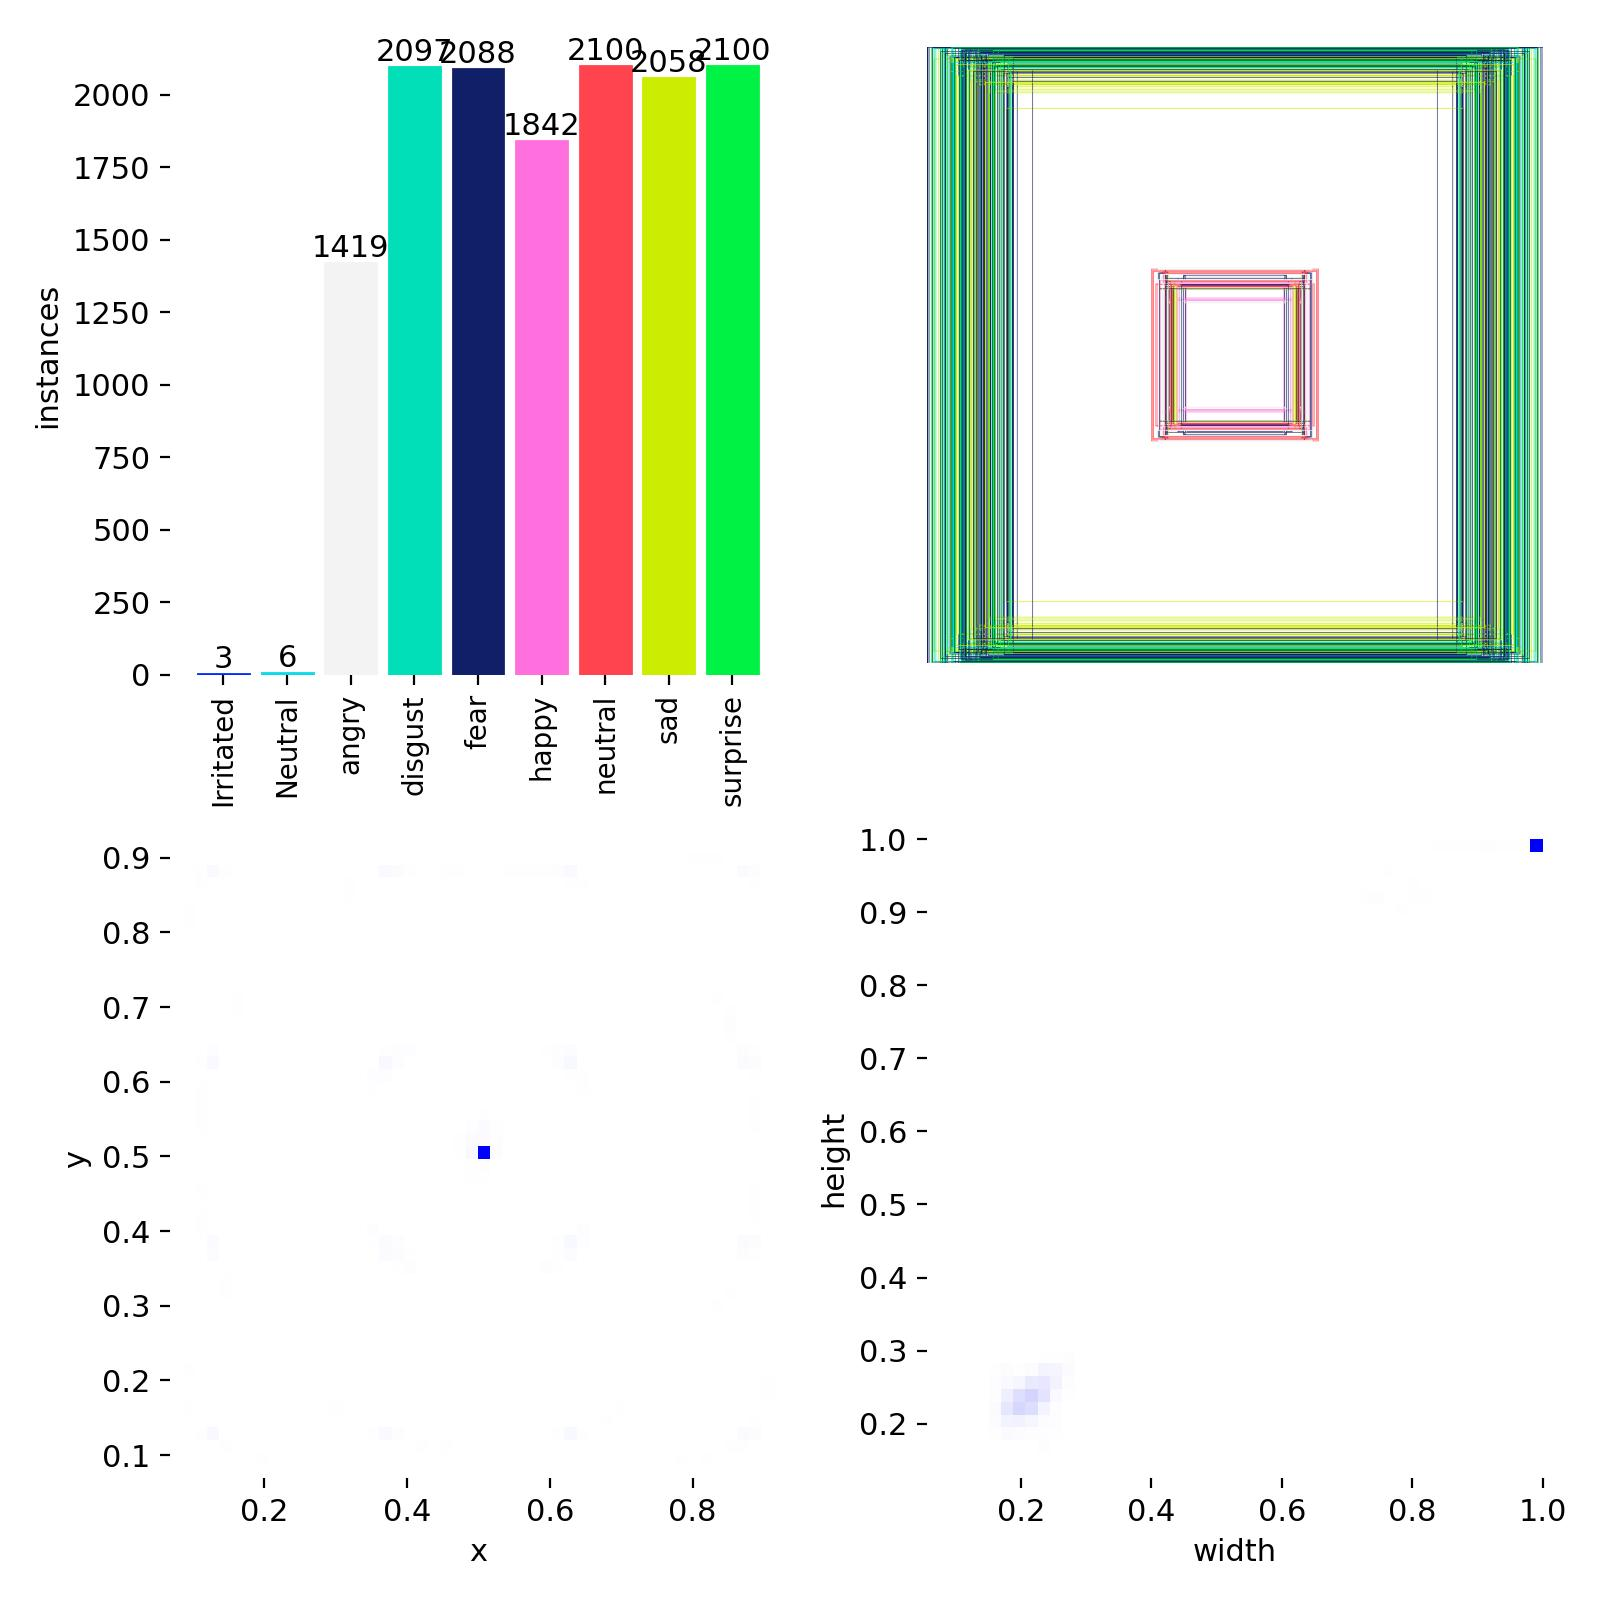

In [ ]:
Image("/content/runs/detect/train/labels.jpg",width=600)

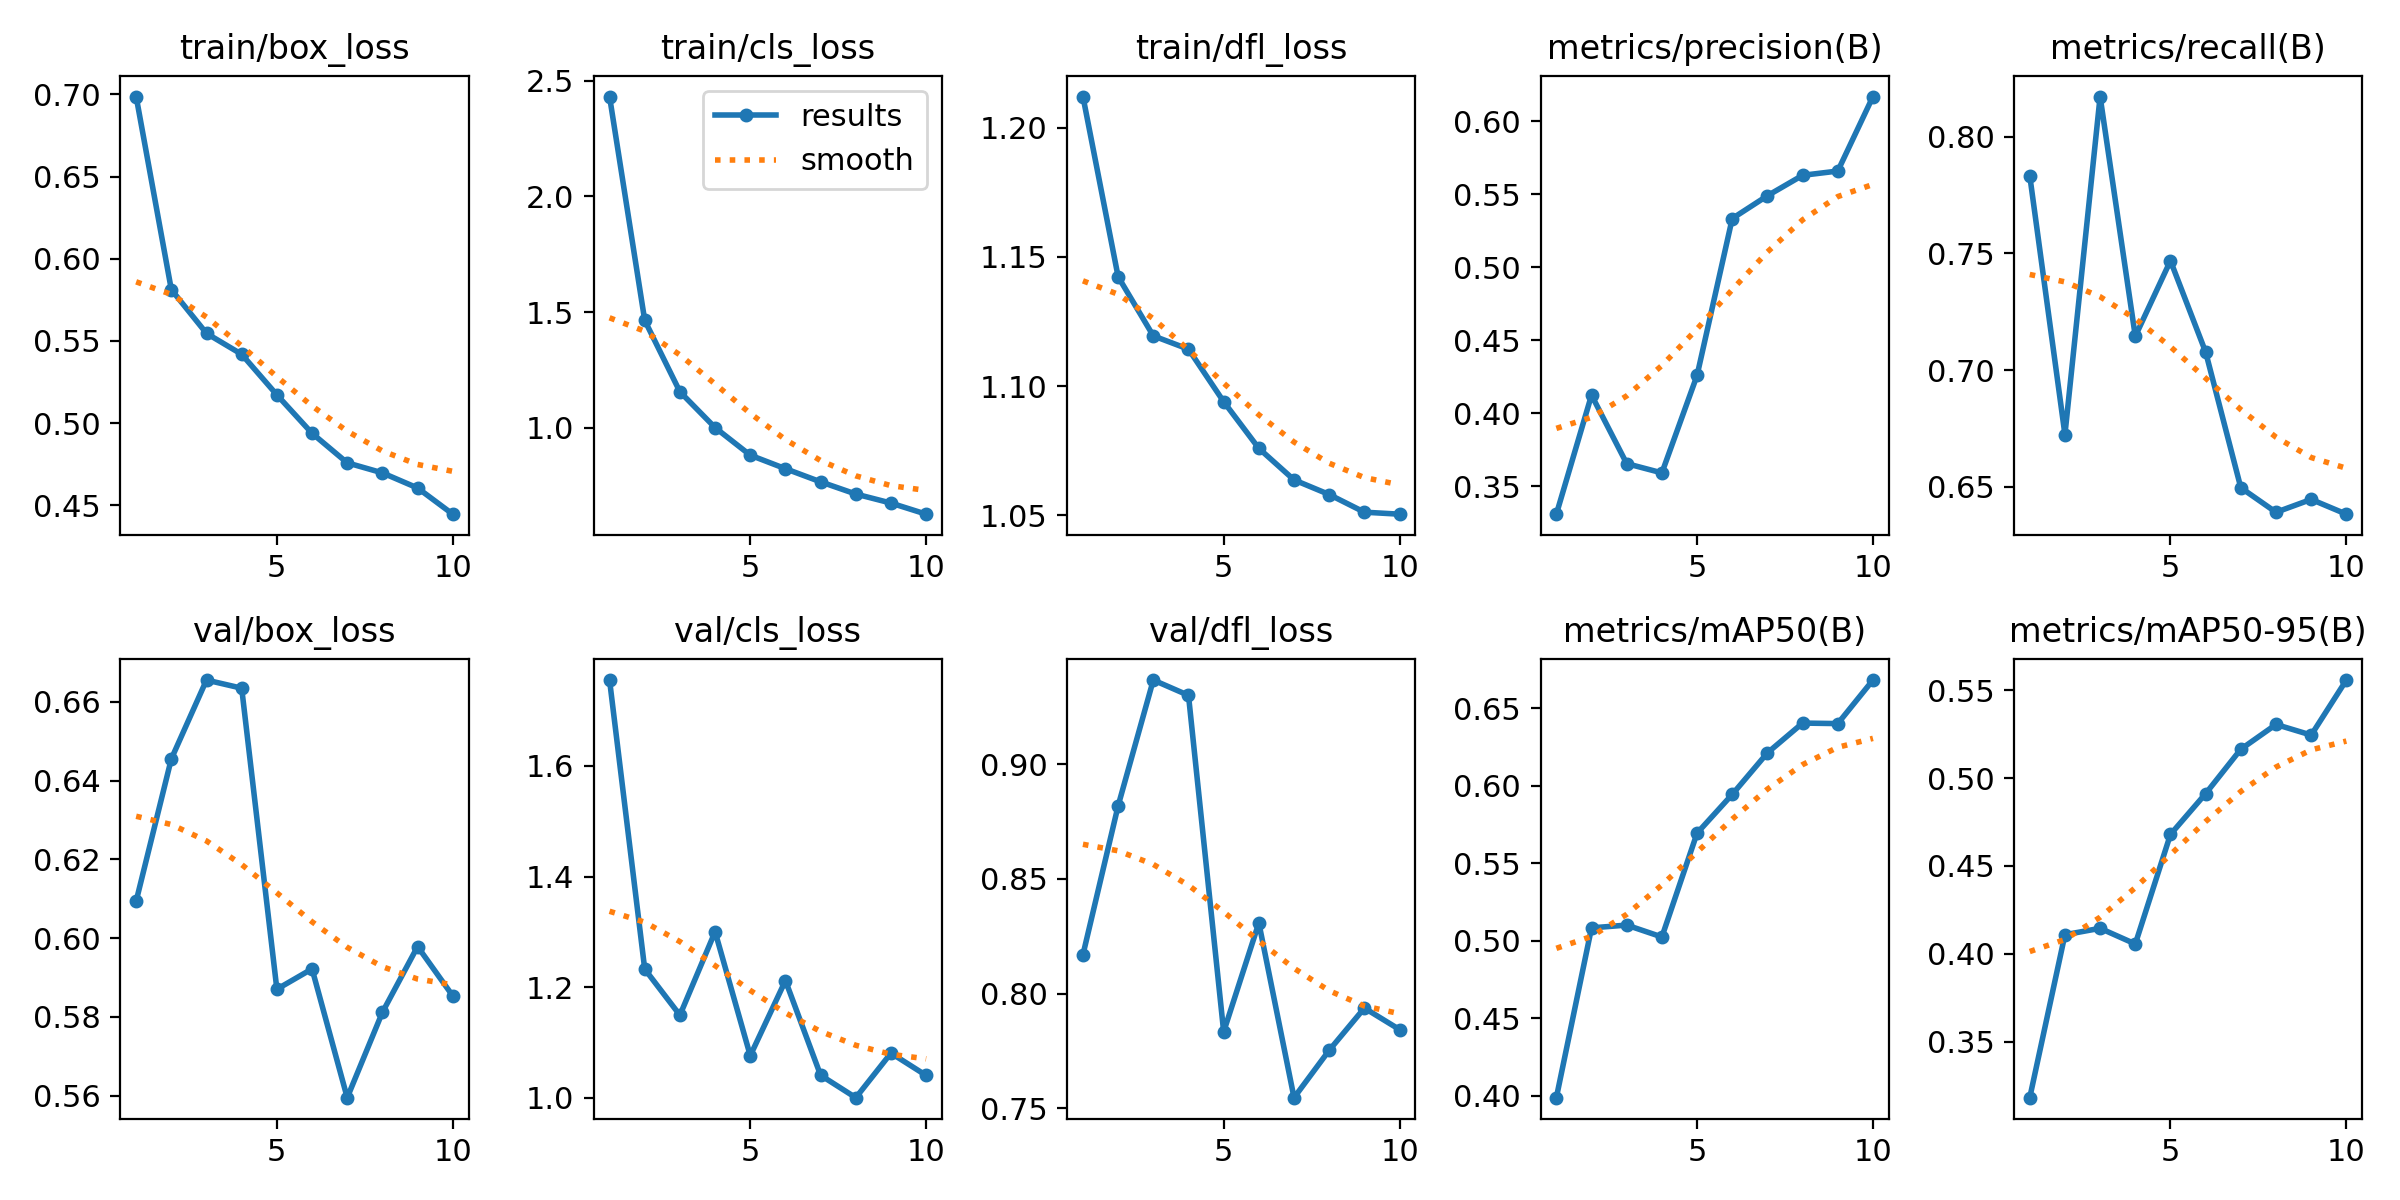

In [ ]:
Image("/content/runs/detect/train/results.png", width=600)

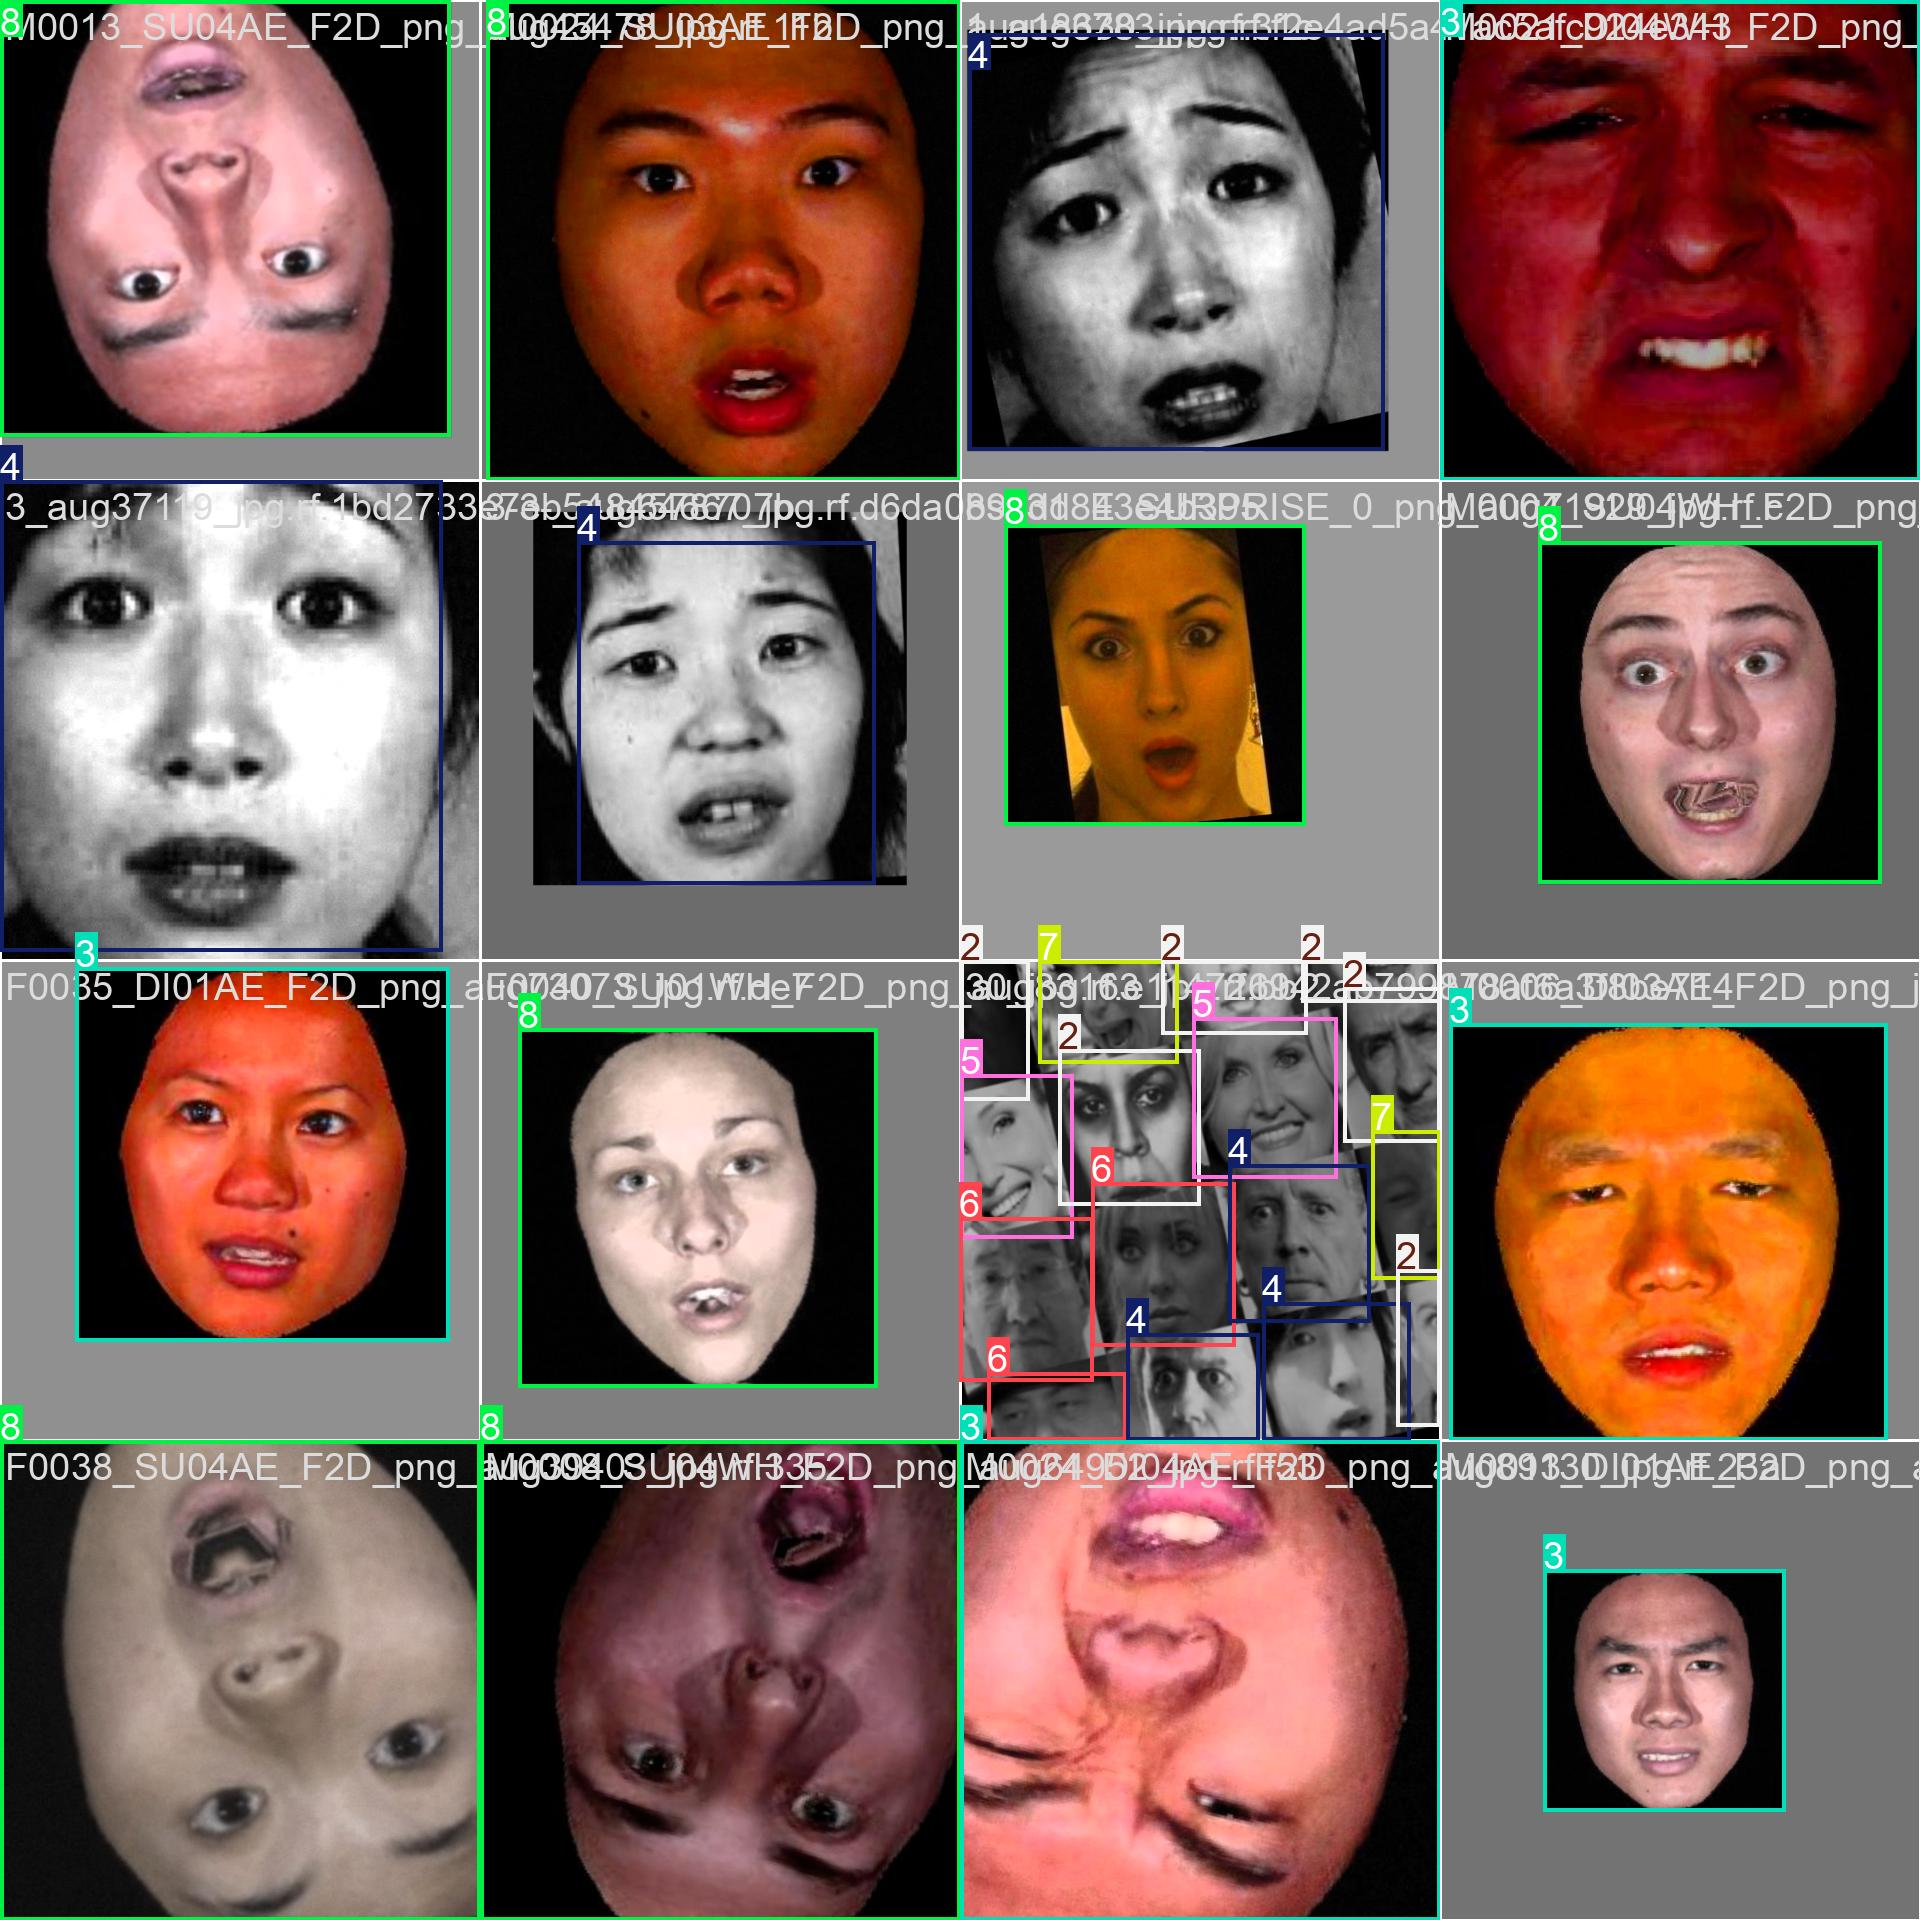

In [ ]:
Image("/content/runs/detect/train/train_batch0.jpg", width=600)

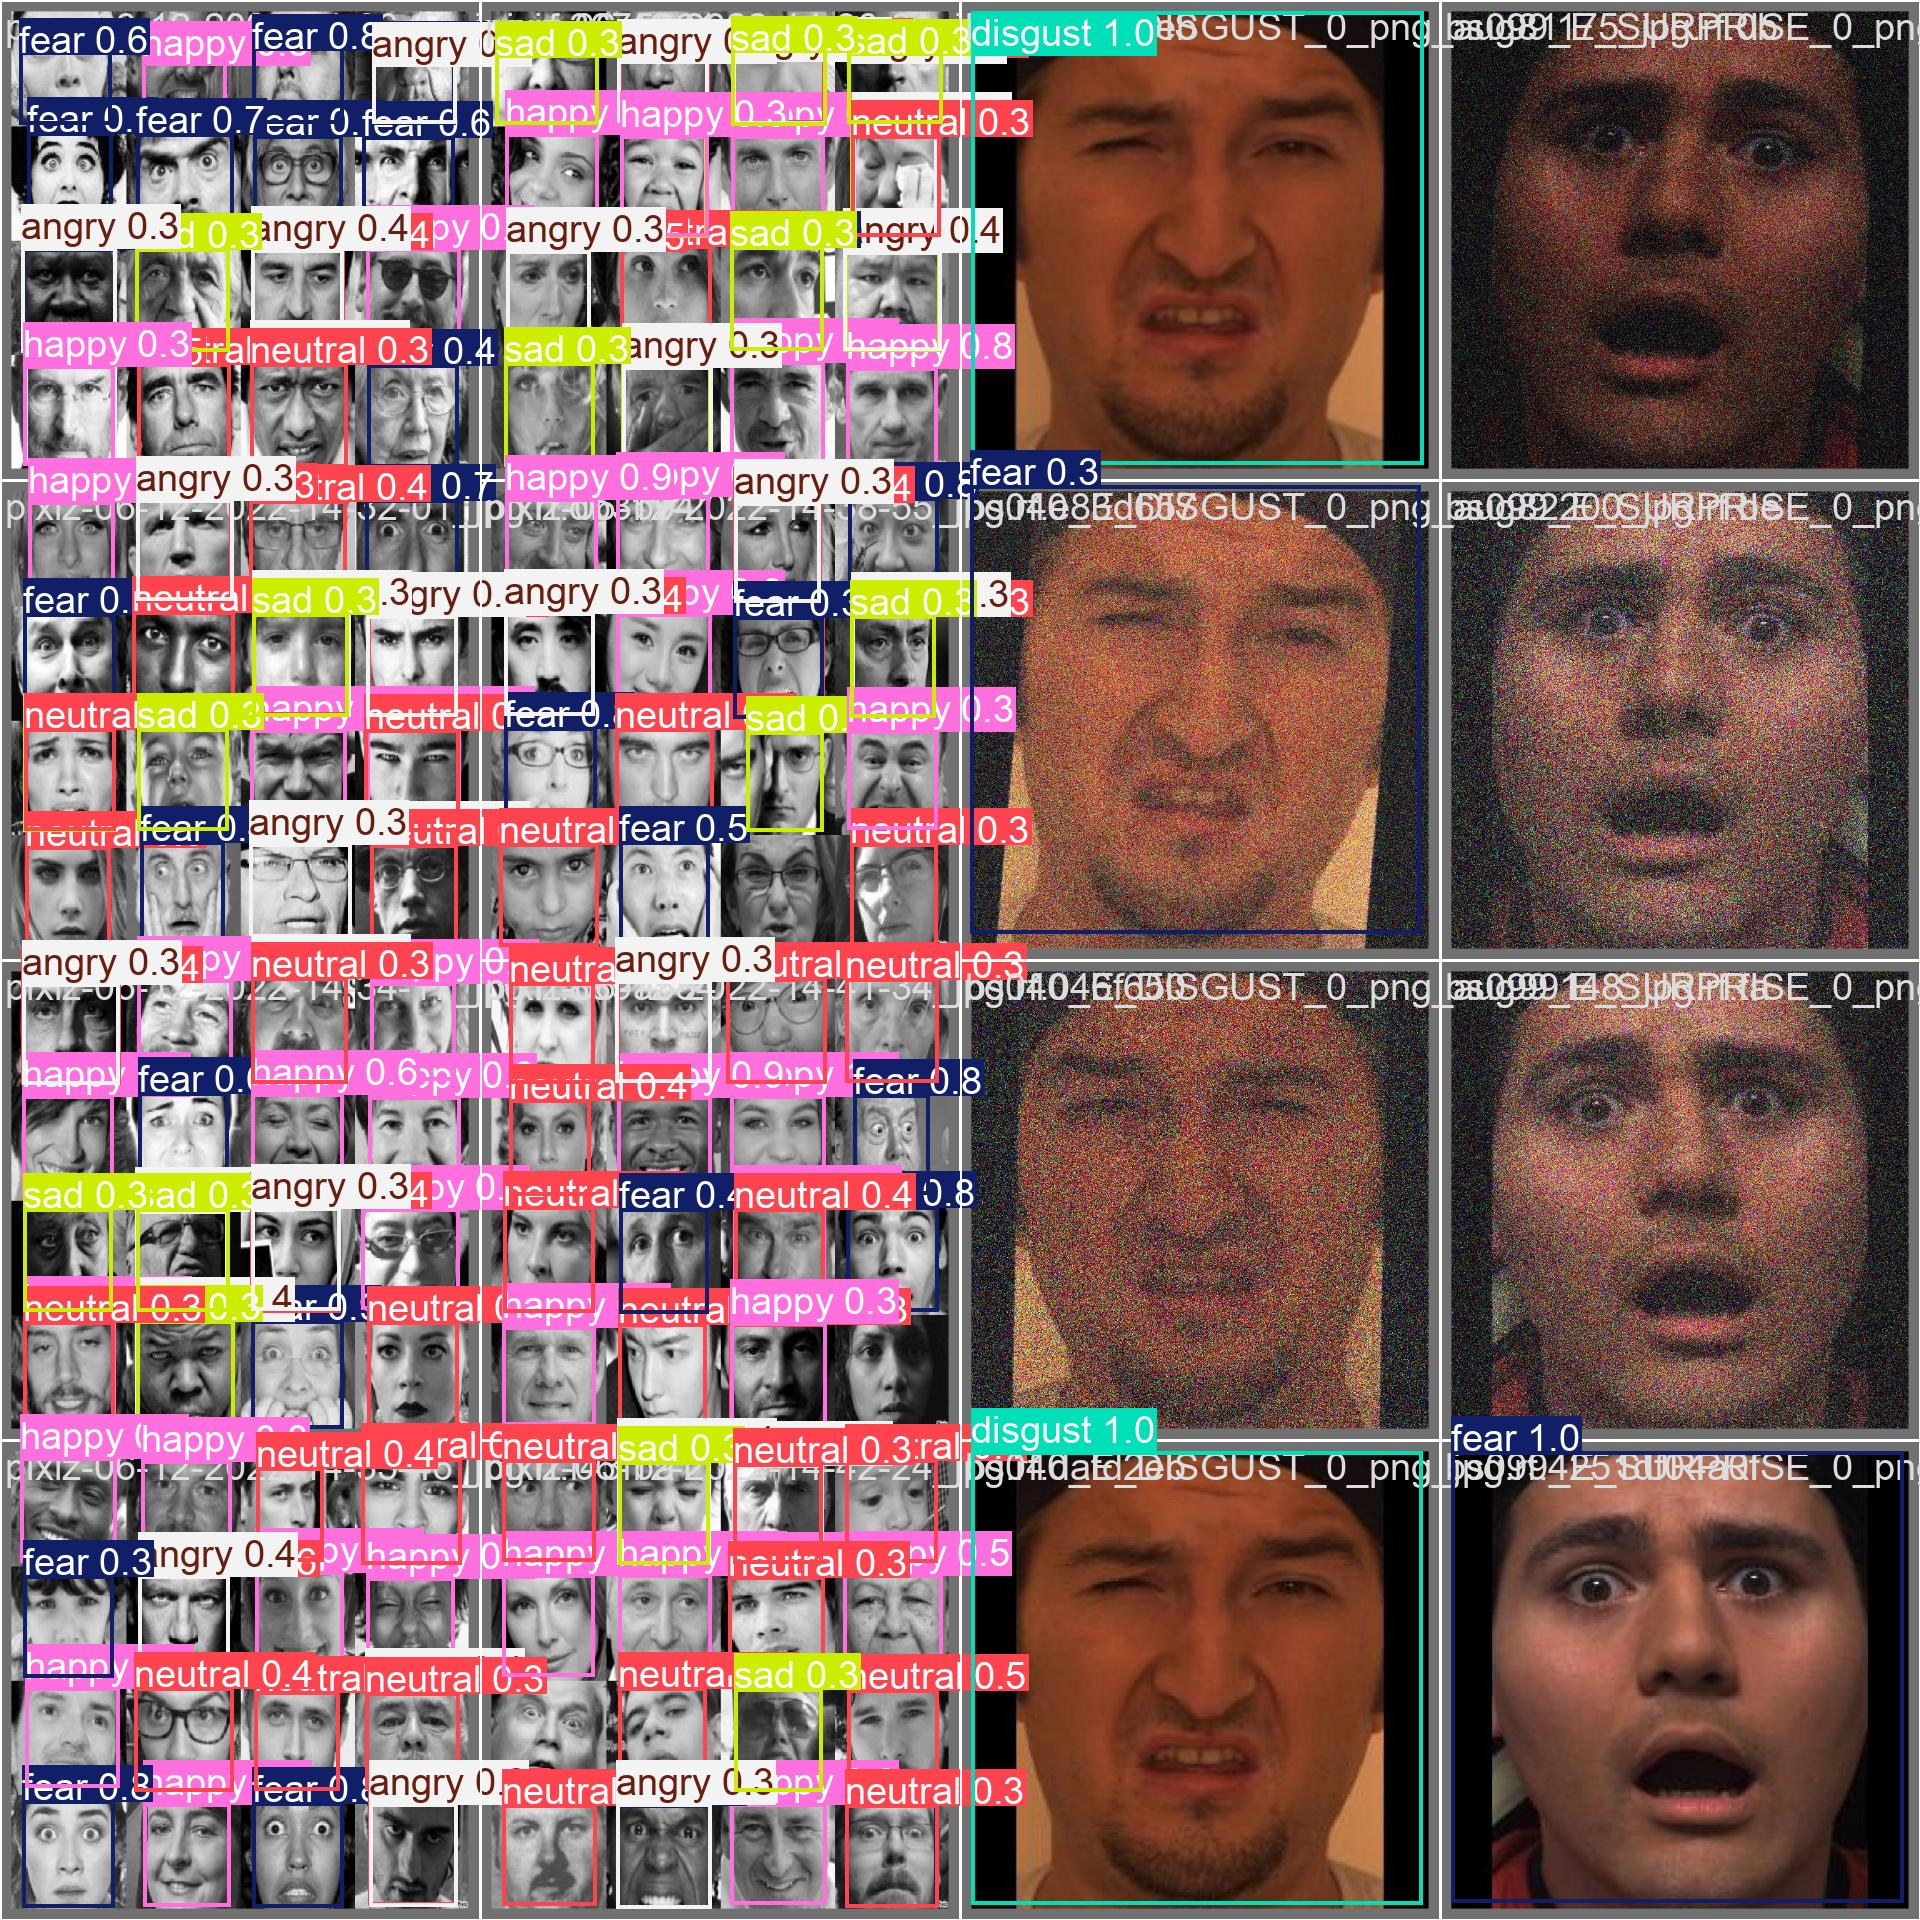

In [ ]:
Image("/content/runs/detect/train/val_batch0_pred.jpg", width=600)

In [ ]:
!yolo task=detect mode=val model="/content/runs/detect/train/weights/best.pt" data={dataset.location}/data.yaml

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,907 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2304.6±1069.2 MB/s, size: 107.4 KB)
val: Scanning /content/Facial-Emotion-Detection-1/valid/labels.cache... 388 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 388/388 81.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 4.4it/s 5.7s
                   all        388       1063      0.617      0.638      0.668      0.555
                 angry         44        135      0.399      0.489      0.427      0.301
               disgust        150        150       0.88      0.684      0.906      0.863
                  fear         60        150       0.56      0.593      0.633      0.484
                 happy         44        176      0.648      0.774      0.815      0.605
               neutral   

In [ ]:
!yolo task=detect mode=predict model="/content/runs/detect/train/weights/best.pt" conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,907 parameters, 0 gradients, 6.3 GFLOPs

image 1/97 /content/Facial-Emotion-Detection-1/test/images/1-4-_jpg.rf.5b7587d3b19c785b6522a9cc9cb9395f.jpg: 640x640 1 disgust, 11.6ms
image 2/97 /content/Facial-Emotion-Detection-1/test/images/1-5-_jpg.rf.495c052dd2445a0ef46afd81b589e3a6.jpg: 640x640 1 disgust, 8.4ms
image 3/97 /content/Facial-Emotion-Detection-1/test/images/1-7-_jpg.rf.3412dc2f2363a845cc69485ef794bbb6.jpg: 640x640 1 disgust, 1 fear, 1 sad, 7.9ms
image 4/97 /content/Facial-Emotion-Detection-1/test/images/1-8-_jpg.rf.9c478c5cb53cae0011ff69b7f87f00de.jpg: 640x640 1 fear, 1 sad, 7.8ms
image 5/97 /content/Facial-Emotion-Detection-1/test/images/11_jpg.rf.f364a68057728f522cd52411cca22572.jpg: 640x640 4 angrys, 4 fears, 1 happy, 9 neutrals, 4 sads, 8.2ms
image 6/97 /content/Facial-Emotion-Detection-1/test/images/16_jpg.rf.17fe03f4f64049bc6f715d85a1aedbb4.jpg: 6

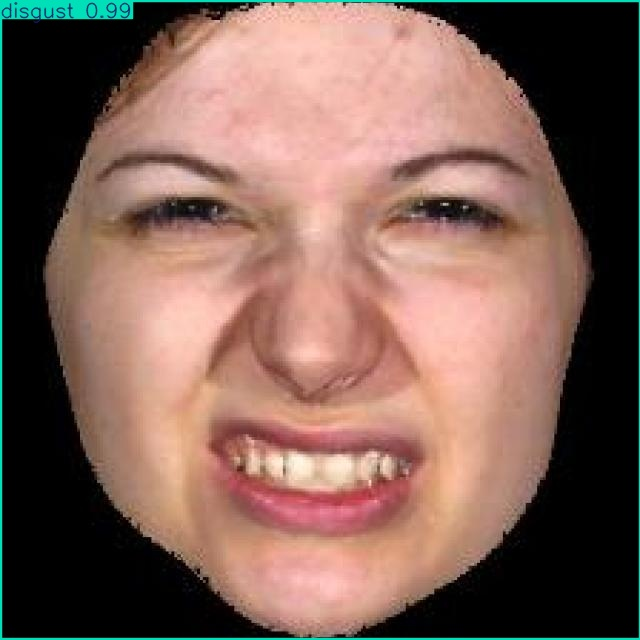

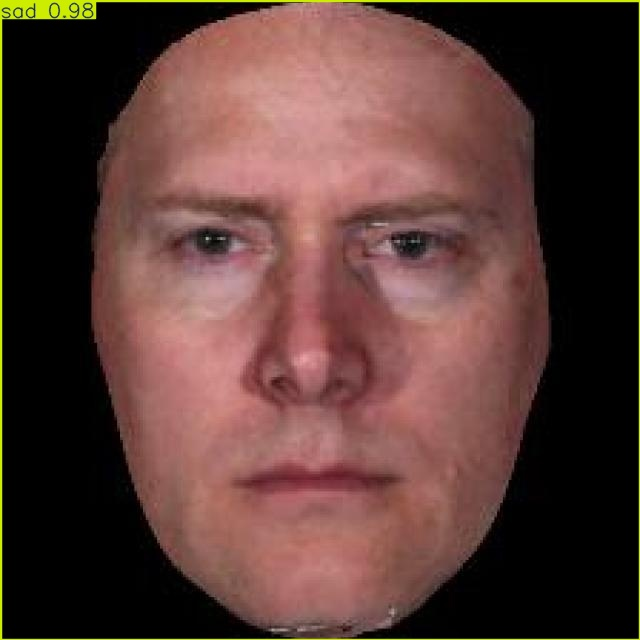

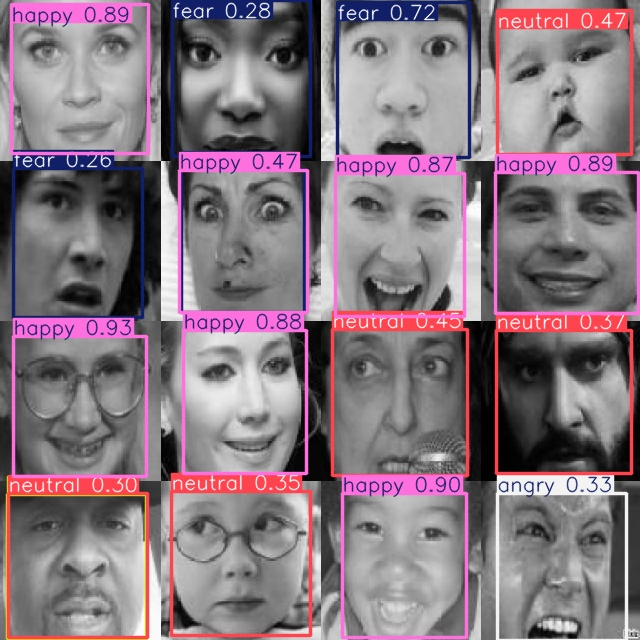

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob('/content/runs/detect/predict*'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[1:4]:
  display(IPyImage(filename=img, width = 600))
  print("\n")